Initializes necessary libraries and defines global paths to the dataset directory and files.

In [19]:
import pandas as pd
import json
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
DATA_DIR = Path("../data")
TRAIN_PATH = DATA_DIR / "train.jsonl"
DEV_PATH = DATA_DIR / "dev.jsonl"
TEST_PATH = DATA_DIR / "test.jsonl"
LABELS_PATH = DATA_DIR / "labels.json"

Loads raw JSONL data and the label dictionary into Python objects for initial processing.

In [3]:
def load_jsonl(file_path):
    """Load data from  file into a list of dictionaries."""
    data = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return []

def load_labels(file_path):
    """Load entity labels from a file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading labels: {e}")
        return []

In [4]:
train_raw = load_jsonl(TRAIN_PATH)
dev_raw = load_jsonl(DEV_PATH)
test_raw = load_jsonl(TEST_PATH)
labels_list = load_labels(LABELS_PATH)

print(f"- Train samples: {len(train_raw)}")
print(f"- Dev samples: {len(dev_raw)}")
print(f"- Test samples: {len(test_raw)}")
print(f"- Unique labels: {len(labels_list)}")

- Train samples: 5027
- Dev samples: 2000
- Test samples: 3000
- Unique labels: 21


Converts raw data into Pandas DataFrames to enable efficient statistical analysis and vectorized operations.

In [5]:
# Convert raw data lists to Pandas DataFrames
df_train = pd.DataFrame(train_raw)
df_dev = pd.DataFrame(dev_raw)
df_test = pd.DataFrame(test_raw)

# Display data structure and the first 5 rows
print("Training Data Preview:")
display(df_train.head())

# Basic info to check for nulls or data type mismatches
print("\nDataFrame Summary:")
df_train.info()

Training Data Preview:


,words,tags
0,"[Đồng_thời, ,, bệnh_viện, tiếp_tục, thực_hiện,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,"["", Số, bệnh_viện, có_thể, tiếp_nhận, bệnh_nhâ...","[O, O, O, O, O, O, O, B-SYMPTOM_AND_DISEASE, I..."
2,"[Ngoài_ra, ,, những, người, tiếp_xúc, gián_tiế...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
3,"[Bà, này, khi, trở, về, quá_cảnh, Doha, (, Qat...","[O, O, O, O, O, O, B-LOCATION, O, B-LOCATION, ..."
4,"["", Bệnh_nhân, 523, "", và, chồng, là, "", bệnh_...","[O, O, B-PATIENT_ID, O, O, O, O, O, O, B-PATIE..."



DataFrame Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   words   5027 non-null   object
 1   tags    5027 non-null   object
dtypes: object(2)
memory usage: 78.7+ KB


Extracts label mappings and performs a consistency check to ensure all tags in the dataset are defined in the metadata.

In [6]:
# Sort by index to ensure consistency
sorted_labels = sorted(labels_list.items(), key=lambda item: item[1])
label_names = [label for label, idx in sorted_labels]

# Create bidirectional mappings
label2id = labels_list
id2label = {v: k for k, v in label2id.items()}

print(f"Total Unique Labels: {len(label_names)}")
print("-" * 30)
print("Label to ID Mapping:")
for label, idx in label2id.items():
    print(f"  {label}: {idx}")

Total Unique Labels: 21
------------------------------
Label to ID Mapping:
  O: 0
  B-PATIENT_ID: 1
  I-PATIENT_ID: 2
  B-NAME: 3
  I-NAME: 4
  B-AGE: 5
  I-AGE: 6
  B-GENDER: 7
  I-GENDER: 8
  B-LOCATION: 9
  I-LOCATION: 10
  B-ORGANIZATION: 11
  I-ORGANIZATION: 12
  B-SYMPTOM_AND_DISEASE: 13
  I-SYMPTOM_AND_DISEASE: 14
  B-TRANSPORTATION: 15
  I-TRANSPORTATION: 16
  B-DATE: 17
  I-DATE: 18
  B-JOB: 19
  I-JOB: 20


In [7]:
# Validation: Check if all tags in the dataset exist in label mapping
unique_tags_in_train = set([tag for tags_list in df_train['tags'] for tag in tags_list])
missing_tags = unique_tags_in_train - set(label_names)

if not missing_tags:
    print("Consistency Check Passed: All tags in training data are defined in labels.json.")
else:
    print(f"Warning: Found tags in data not present in labels.json: {missing_tags}")

Consistency Check Passed: All tags in training data are defined in labels.json.


Verifies that every sentence has the exact same number of words and tags

In [24]:
# Check for length consistency between 'words' and 'tags' columns
df_train['is_consistent'] = df_train.apply(lambda x: len(x['words']) == len(x['tags']), axis=1)
inconsistent_rows = df_train[df_train['is_consistent'] == False]

if len(inconsistent_rows) == 0:
    print("All samples have matching word and tag counts.")
else:
    print(f"Warning: Found {len(inconsistent_rows)} inconsistent samples!")
    print("Sample indices with issues:", inconsistent_rows.index.tolist())
    
    # Preview the first inconsistent sample for debugging
    idx = inconsistent_rows.index[0]
    print(f"\nExample of Mismatch at Index {idx}:")
    print(f"- Words count: {len(df_train.loc[idx, 'words'])}")
    print(f"- Tags count: {len(df_train.loc[idx, 'tags'])}")

All samples have matching word and tag counts.


Calculates basic statistics for each split, including sample counts and sentence length metrics.

In [8]:
stats = []
for name, df in zip(["Train", "Dev", "Test"], [df_train, df_dev, df_test]):
    stats.append({
        "Split": name,
        "Samples": len(df),
        "Avg Sentence Length": df['words'].apply(len).mean(),
        "Max Sentence Length": df['words'].apply(len).max(),
        "Min Sentence Length": df['words'].apply(len).min()
    })

df_stats = pd.DataFrame(stats)
print("Dataset Splitting Statistics:")
display(df_stats)

Dataset Splitting Statistics:


,Split,Samples,Avg Sentence Length,Max Sentence Length,Min Sentence Length
0,Train,5027,26.359857,161,6
1,Dev,2000,28.141500,138,7
2,Test,3000,28.559333,162,7


Flattens tag sequences to analyze the distribution of each entity type across the dataset.

In [11]:
def get_tag_counts(df, tag_col='tags'):
    """Flatten all tags in the dataframe and return a Counter object."""
    all_tags = [tag for tags_list in df[tag_col] for tag in tags_list]
    return Counter(all_tags)

train_tag_counts = get_tag_counts(df_train)
dev_tag_counts = get_tag_counts(df_dev)
test_tag_counts = get_tag_counts(df_test)

# Summary dataframe for tag distribution across splits
df_dist = pd.DataFrame({
    'Train': train_tag_counts,
    'Dev': dev_tag_counts,
    'Test': test_tag_counts
}).fillna(0).astype(int)

# Sort by Train frequency descending
df_dist = df_dist.sort_values(by='Train', ascending=False)
print("Tag Distribution across splits:")
print(df_dist)

Tag Distribution across splits:
                        Train    Dev   Test
O                      104750  42166  63546
B-LOCATION               5398   2737   4441
I-LOCATION               5242   2993   4918
B-PATIENT_ID             3240   1276   2005
B-DATE                   2549   1103   1654
I-ORGANIZATION           2545   1455   2014
I-DATE                   2500   1118   1750
I-SYMPTOM_AND_DISEASE    1552    987   1486
B-SYMPTOM_AND_DISEASE    1439    766   1136
B-ORGANIZATION           1137    551    771
B-AGE                     682    361    582
B-GENDER                  542    277    462
B-NAME                    349    188    318
B-TRANSPORTATION          226     87    193
B-JOB                     205    132    173
I-TRANSPORTATION           67     25     69
I-JOB                      62     49    114
I-NAME                     13      5     13
I-PATIENT_ID               11      7     27
I-AGE                       2      0      6


Visualizes the frequency of entity tags using bar charts, specifically filtering out the dominant "O" tag for better clarity.

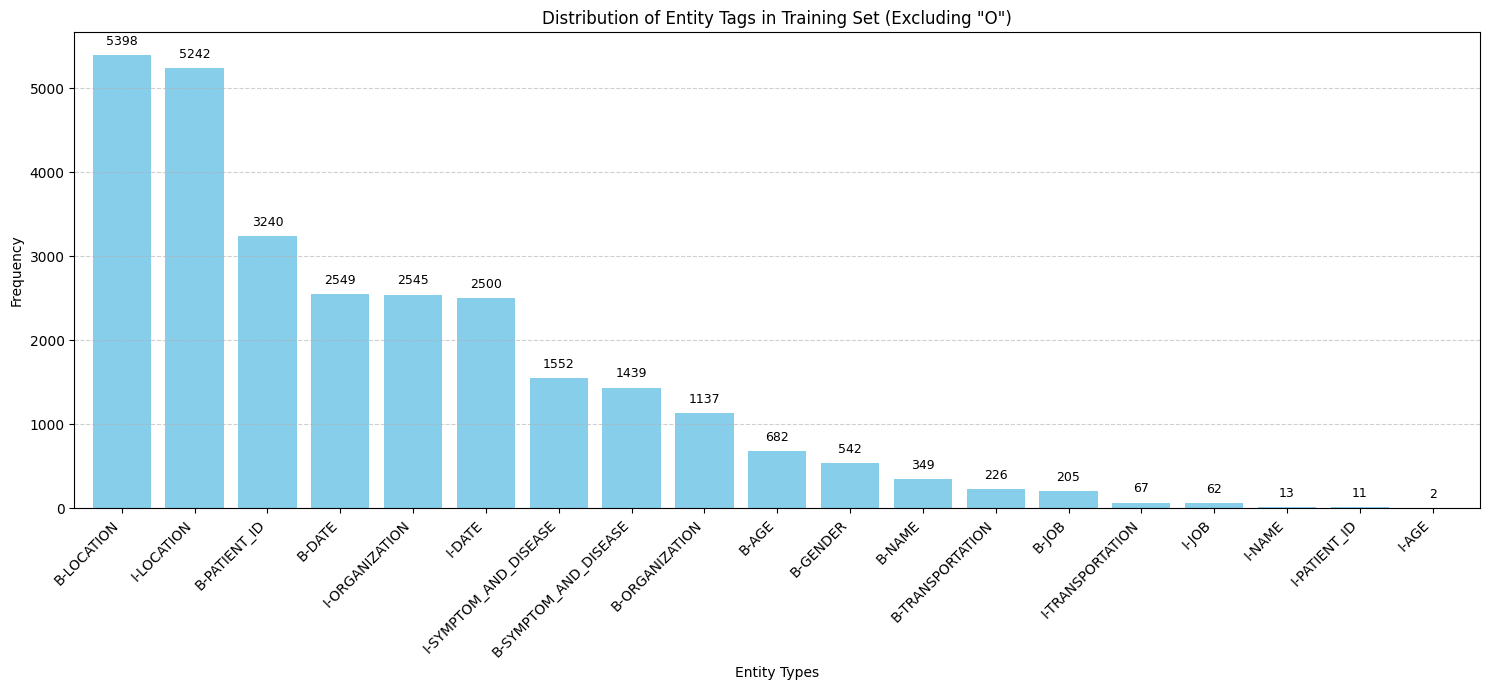

In [21]:
# Filter out the 'O' tag for better visualization
df_entities_only = df_dist.drop(index='O', errors='ignore')

plt.figure(figsize=(15, 7))
ax = df_entities_only['Train'].plot(kind='bar', color='skyblue', width=0.8)

plt.title('Distribution of Entity Tags in Training Set (Excluding "O")')
plt.xlabel('Entity Types')
plt.ylabel('Frequency')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

Plots the distribution of sentence lengths to help determine the optimal maximum sequence length for model training.

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Mean length: 26.36
95th percentile: 50.00
Max length: 161


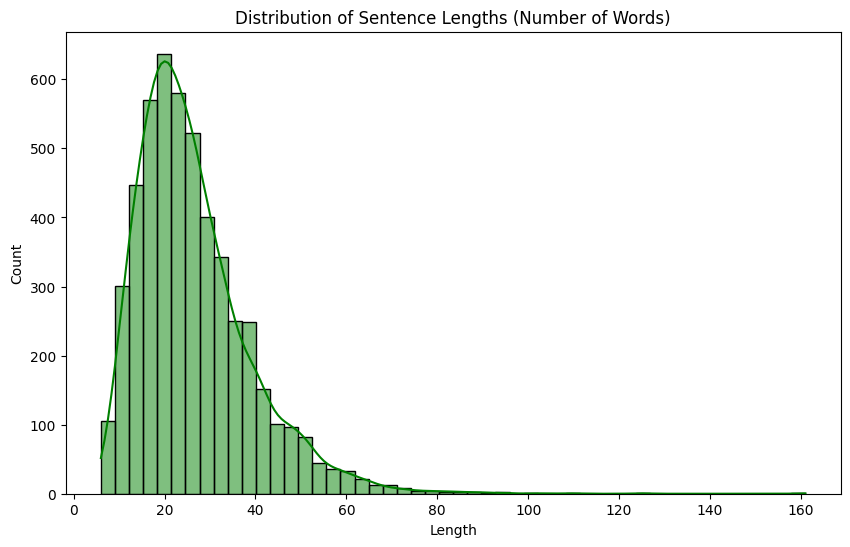

In [14]:
# Calculate length of each sentence
df_train['sentence_len'] = df_train['words'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df_train['sentence_len'], bins=50, kde=True, color='green')
plt.title('Distribution of Sentence Lengths (Number of Words)')
plt.xlabel('Length')
plt.ylabel('Count')

# Statistics for sequence length
print(f"Mean length: {df_train['sentence_len'].mean():.2f}")
print(f"95th percentile: {df_train['sentence_len'].quantile(0.95):.2f}")
print(f"Max length: {df_train['sentence_len'].max()}")
plt.show()

Analyzes entity density per sentence to identify the concentration of entities and the frequency of sentences without any labeled tags.

In [18]:
def count_entities(tags_list):
    """Count number of B- tags to identify number of unique entities."""
    return len([t for t in tags_list if t.startswith('B-')])

df_train['entity_count'] = df_train['tags'].apply(count_entities)

print("Entity Density Statistics:")
print(df_train['entity_count'].describe())

Entity Density Statistics:
count    5027.000000
mean        3.136463
std         2.573024
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        57.000000
Name: entity_count, dtype: float64


Performs a sanity check to verify that the number of words matches the number of tags for every sample to prevent errors during training.

In [17]:
# Check how many sentences have zero entities
no_entity_sentences = (df_train['entity_count'] == 0).sum()
print(f"Sentences with zero entities: {no_entity_sentences} ({no_entity_sentences/len(df_train)*100:.2f}%)")

Sentences with zero entities: 421 (8.37%)


Generates a word cloud from entity-tagged tokens to visually identify the most prominent words within the labeled data.

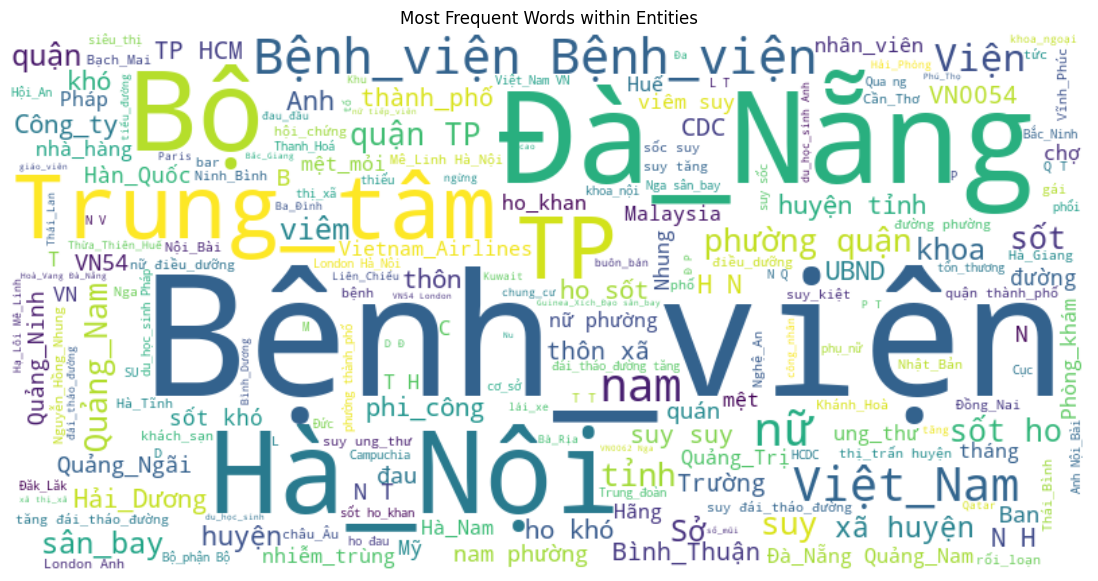

In [20]:
def get_entity_words(df, target_entity_prefix='B-'):
    """Collect words associated with specific entity tags."""
    entity_words = []
    for words, tags in zip(df['words'], df['tags']):
        for w, t in zip(words, tags):
            if t.startswith(target_entity_prefix):
                entity_words.append(w)
    return " ".join(entity_words)

# Generate word cloud for all entities
all_entity_text = get_entity_words(df_train)
if all_entity_text.strip():
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_entity_text)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Frequent Words within Entities')
    plt.show()
else:
    print("No entities found to generate word cloud.")

Identifies the most frequent words for each entity type to understand the specific vocabulary associated with target labels.

In [25]:
def get_top_tokens_for_tag(df, target_tag, top_n=10):
    """Extract the most frequent words associated with a specific entity tag."""
    tokens = []
    for words, tags in zip(df['words'], df['tags']):
        for w, t in zip(words, tags):
            if t == target_tag:
                tokens.append(w)
    return Counter(tokens).most_common(top_n)

# Identify the top 5 non-'O' tags 
top_entities = df_entities_only.index[:5].tolist()

print("Top 10 most frequent tokens for each main entity:")
print("-" * 50)

for entity in top_entities:
    top_tokens = get_top_tokens_for_tag(df_train, entity)
    print(f"Entity: {entity}")
    token_list = [f"{word} ({count})" for word, count in top_tokens]
    print("  " + ", ".join(token_list))
    print("-" * 50)

Top 10 most frequent tokens for each main entity:
--------------------------------------------------
Entity: B-LOCATION
  Bệnh_viện (968), Đà_Nẵng (414), Hà_Nội (326), quận (254), Việt_Nam (224), TP (188), huyện (166), phường (139), tỉnh (128), TP. (127)
--------------------------------------------------
Entity: I-LOCATION
  Đà_Nẵng (349), HCM (264), Bệnh (248), 2 (177), Trung_ương (162), nhiệt_đới (150), cơ_sở (146), Nhiệt_đới (137), Bạch_Mai (132), Đa_khoa (104)
--------------------------------------------------
Entity: B-PATIENT_ID
  17 (131), 91 (106), 416 (82), 243 (77), 34 (67), 418 (50), 19 (47), 22 (34), 86 (32), 21 (30)
--------------------------------------------------
Entity: B-DATE
  13 (70), 25 (60), 21 (55), 15 (55), 20 (54), 18 (53), 29 (53), 22 (50), 16 (50), 27 (50)
--------------------------------------------------
Entity: I-ORGANIZATION
  Y_tế (385), Kiểm_soát (120), bệnh_tật (119), Hà_Nội (101), Đà_Nẵng (84), HCM (83), Vệ_sinh (77), Trung_ương (76), TP. (69), tỉnh (

Calculates the Out-of-Vocabulary (OOV) rate for Dev and Test sets to evaluate how many new words the model will encounter.

In [27]:
def get_vocab(df):
    """Extract a set of all unique lowercase words from the dataframe."""
    return set([w.lower() for words in df['words'] for w in words])

train_vocab = get_vocab(df_train)
dev_vocab = get_vocab(df_dev)
test_vocab = get_vocab(df_test)

def calculate_oov(target_vocab, reference_vocab):
    """Calculate the number and percentage of OOV tokens."""
    oov_tokens = [w for w in target_vocab if w not in reference_vocab]
    pct = (len(oov_tokens) / len(target_vocab)) * 100 if target_vocab else 0
    return oov_tokens, pct

oov_dev, pct_dev = calculate_oov(dev_vocab, train_vocab)
oov_test, pct_test = calculate_oov(test_vocab, train_vocab)

print(f"Vocabulary Statistics:")
print(f"- Train vocab size: {len(train_vocab)}")
print(f"- Dev OOV: {len(oov_dev)} tokens ({pct_dev:.2f}%)")
print(f"- Test OOV: {len(oov_test)} tokens ({pct_test:.2f}%)")

Vocabulary Statistics:
- Train vocab size: 4739
- Dev OOV: 1145 tokens (28.51%)
- Test OOV: 1804 tokens (35.54%)


Checks for duplicate sentences across different data splits to detect potential data leakage and ensure evaluation integrity.

In [29]:
def check_overlap(df_a, df_b, name_a, name_b):
    """Identify duplicate sentences based on the 'words' column between two dataframes."""
    # Convert lists to tuples to make them hashable for comparison
    series_a = df_a['words'].apply(tuple)
    series_b = df_b['words'].apply(tuple)
    
    overlap = set(series_a).intersection(set(series_b))
    print(f"Overlap between {name_a} and {name_b}: {len(overlap)} duplicate sentences")
    return overlap

print("Data Leakage Analysis:")
overlap_train_dev = check_overlap(df_train, df_dev, "Train", "Dev")
overlap_train_test = check_overlap(df_train, df_test, "Train", "Test")

Data Leakage Analysis:
Overlap between Train and Dev: 0 duplicate sentences
Overlap between Train and Test: 1 duplicate sentences
